In [ ]:
#####################################################################
###  ライブラリのインストール
#####################################################################
%pip install torch

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# =====================================================================
#  インポート
# =====================================================================
import torch

In [ ]:
# =====================================================================
#  ディレクトリ定数
# =====================================================================
DATA_DIR = "../data"

In [ ]:
# =====================================================================
#  VRAM容量に応じたフラグの設定
# =====================================================================
#  RowVRAMGPU_flg : 実行GPUのVRAM容量が4GB未満であるかどうかのフラグ
# =====================================================================
#   経緯   
#     GoogleColabや自宅PCと支給PCのGPUスペックに差があり
#     およそ25倍の処理時間がかかった
#     なのでVRAM容量に応じて学習パラメータを変えるためのフラグを設定する
# =====================================================================

# 低VRAM容量フラグの初期値
RowVRAMGPU_flg = False

# 実行GPUのVRAM容量が4GB未満であれば低VRAM容量フラグを立てる
if torch.cuda.is_available():
    gpu_id = 0
    total_memory = torch.cuda.get_device_properties(gpu_id).total_memory
    
    if (total_memory / 1024**3) <= 4:
        RowVRAMGPU_flg = True
    else:
        RowVRAMGPU_flg = False

print(f"GPU名: {torch.cuda.get_device_name(gpu_id)}")
print(f"総VRAM: {total_memory / 1024**3:.2f} GB")

GPU名: NVIDIA GeForce RTX 3070
総VRAM: 8.00 GB


train画像数     : 60000
X_train shape  : (60000, 28, 28)
test画像数      : 10000
X_test shape   : (10000, 28, 28)
         filename                          path
0     train_0.jpg     ..\data\train\train_0.jpg
1     train_1.jpg     ..\data\train\train_1.jpg
2    train_10.jpg    ..\data\train\train_10.jpg
3   train_100.jpg   ..\data\train\train_100.jpg
4  train_1000.jpg  ..\data\train\train_1000.jpg


C:\Users\youto\AppData\Local\Temp\ipykernel_26256\2049080049.py:74: UserWarning: Glyph 12469 (\N{KATAKANA LETTER SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\youto\AppData\Local\Temp\ipykernel_26256\2049080049.py:74: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\youto\AppData\Local\Temp\ipykernel_26256\2049080049.py:74: UserWarning: Glyph 12503 (\N{KATAKANA LETTER PU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\youto\AppData\Local\Temp\ipykernel_26256\2049080049.py:74: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\youto\AppData\Local\Temp\ipykernel_26256\2049080049.py:74: UserWarning: Glyph 30011 (\N{CJK UNIFIED IDEOGRAPH-753B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\youto\AppData\Local\Temp\ipykernel_26256\2049080049.py:74: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) mi

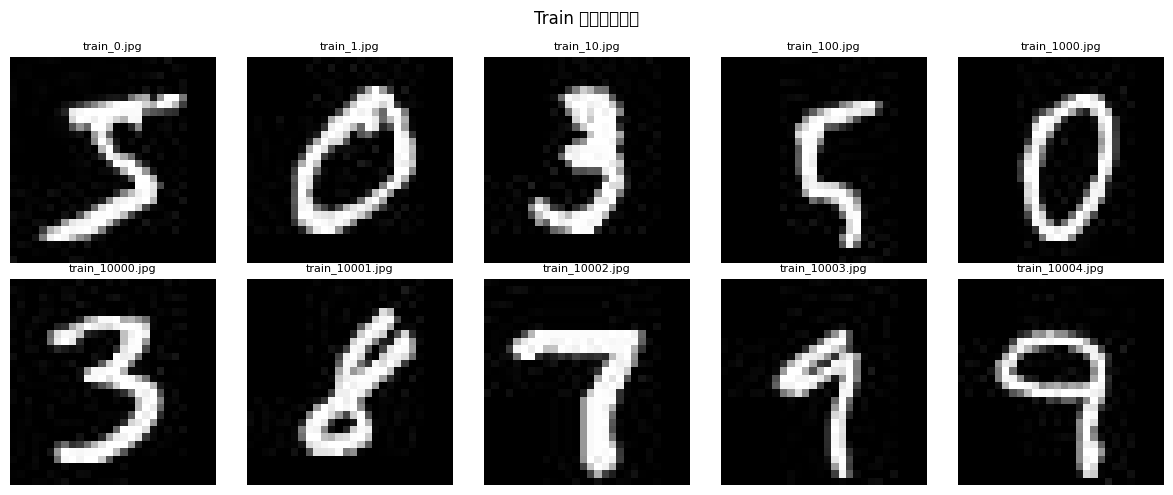

In [5]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

# =============================
# 1. 画像パスを再帰的に収集する関数
# =============================
def collect_image_paths(root_dir, extension=".jpg"):
    """ディレクトリ以下のjpg画像パスを全て収集"""
    root = Path(root_dir)
    paths = sorted(root.rglob(f"*{extension}"))  # 再帰的に検索
    return paths

# =============================
# 2. 画像を読み込む関数
# =============================
def load_images_from_paths(paths, img_size=(28, 28), grayscale=True):
    """
    paths    : Pathオブジェクトのリスト
    img_size : リサイズ後のサイズ
    grayscale: グレースケールで読み込むか
    """
    images = []
    file_names = []
    mode = "L" if grayscale else "RGB"

    for path in paths:
        img = Image.open(path).convert(mode).resize(img_size)
        images.append(np.array(img))
        file_names.append(path.name)

    return np.array(images), file_names

# =============================
# 3. trainデータの読み込み
# =============================
train_paths = collect_image_paths("../data/train/")
X_train, train_filenames = load_images_from_paths(train_paths)
X_train = X_train / 255.0  # 正規化

print(f"train画像数     : {len(train_paths)}")
print(f"X_train shape  : {X_train.shape}")

# =============================
# 4. testデータの読み込み
# =============================
test_paths = collect_image_paths("../data/test/")
X_test, test_filenames = load_images_from_paths(test_paths)
X_test = X_test / 255.0  # 正規化

print(f"test画像数      : {len(test_paths)}")
print(f"X_test shape   : {X_test.shape}")

# =============================
# 5. ファイル名をDataFrameで管理
# =============================
train_df = pd.DataFrame({"filename": train_filenames, "path": [str(p) for p in train_paths]})
test_df  = pd.DataFrame({"filename": test_filenames,  "path": [str(p) for p in test_paths]})

print(train_df.head())

# =============================
# 6. サンプル画像の表示確認
# =============================
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_train[i], cmap="gray")
    ax.set_title(train_filenames[i], fontsize=8)
    ax.axis("off")
plt.suptitle("Train サンプル画像")
plt.tight_layout()
plt.show()